In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import tensorflow as tf

from rembg import remove
from tqdm.notebook import tqdm

seed = 1234

In [3]:
# Loading training, testing, and validation directories
train_dir = 'C:/Ubuntu_files/w281/project/Train'
test_dir = 'C:/Ubuntu_files/w281/project/Test'
val_dir = 'C:/Ubuntu_files/w281/project/Validation'

In [4]:
train = tf.keras.utils.image_dataset_from_directory(
    train_dir,  # Directory where the Training images are located
    labels = 'inferred', # Classes will be inferred according to the structure of the directory
    label_mode = 'categorical',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    # Number of processed samples before updating the model's weights
    image_size = (256, 256), # Defining a fixed dimension for all images
    shuffle = False,  # Shuffling data
    seed = seed,  # Random seed for shuffling and transformations
    validation_split = 0, # We don't need to create a validation set from the training set
    crop_to_aspect_ratio = True # Resize images without aspect ratio distortion
)

Found 1322 files belonging to 3 classes.


In [5]:
test = tf.keras.utils.image_dataset_from_directory(
    test_dir,  
    labels = 'inferred', 
    label_mode = 'categorical',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256), 
    shuffle = False,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 150 files belonging to 3 classes.


In [6]:
validation = tf.keras.utils.image_dataset_from_directory(
    val_dir,  
    labels = 'inferred', 
    label_mode = 'categorical',
    class_names = ['Healthy', 'Powdery', 'Rust'],
    batch_size = 16,    
    image_size = (256, 256),
    shuffle = False,  
    seed = seed,  
    validation_split = 0, 
    crop_to_aspect_ratio = True 
)

Found 60 files belonging to 3 classes.


In [13]:
train_images = np.concatenate([np.round(x.numpy()).astype(np.uint8) for x, _ in train])
train_labels = np.concatenate([y.numpy() for _, y in train])

In [35]:
train_images_processed = np.stack([np.array(remove(image))[:, :, :3] for image in tqdm(train_images[:10], file=sys.stdout)]) #remove alpha channel while we're at it

100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


In [25]:
train_images_processed

array([[[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        ...,

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]],


       [[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[0, 0, 0],
         [0,

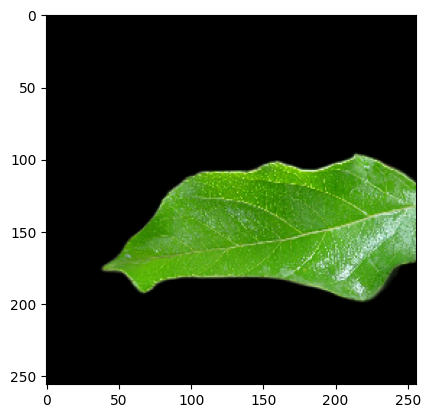

In [26]:
plt.imshow(train_images_processed[0])

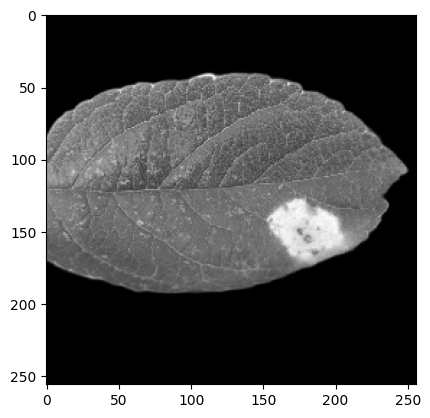

In [457]:
plt.imshow(train_images_processed[1296][:, :, 0], cmap='gray')


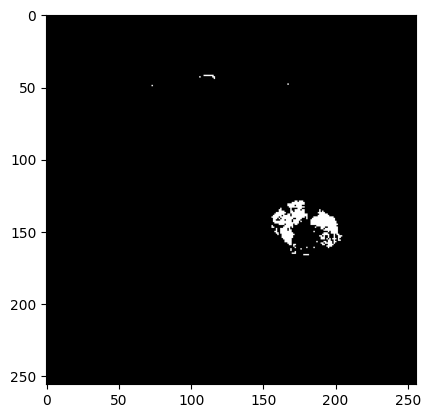

In [420]:
img = train_images_processed[1296].copy()

img_uint8 = np.clip(img * 255, 0, 255).astype(np.uint8)
gray_img = img_uint8[:, :, 0]
flat = gray_img.flatten()

threshold = np.quantile(flat, 0.98)
abs_threshold = 0.9 * 255

rounded_gray_image = np.where((gray_img >= threshold) & (gray_img >= abs_threshold), 255, 0).astype(np.uint8)
#rounded_gray_image = np.where((gray_img >= abs_threshold), 255, 0).astype(np.uint8)
plt.imshow(rounded_gray_image, cmap='gray')

3


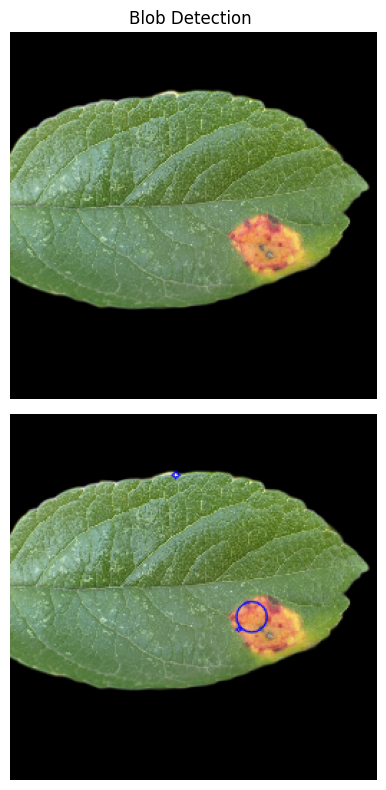

In [417]:
# Setup SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Example parameter tuning (adjust as needed for your blobs)
params.filterByColor = True
params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
params.filterByArea = True
params.minArea = 1              # minimum area of blob
params.maxArea = 5000            # maximum area of blob
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

detector = cv2.SimpleBlobDetector_create(params)
blobs = detector.detect(rounded_gray_image)
print(len(blobs))

output = img_uint8.copy()
output_with_blobs = cv2.drawKeypoints(
    output,
    blobs,
    np.array([]),
    (0,0,255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


fig, axs = plt.subplots(2, 1, figsize=(12,8))
axs[0].set_title("Blob Detection ")
axs[0].imshow(img_uint8)
axs[0].axis('off')

axs[1].imshow(cv2.cvtColor(output_with_blobs, cv2.COLOR_BGR2RGB))
axs[1].imshow(output_with_blobs)
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [442]:
def count_blobs(images, params, soft_percentile, hard_percentile, cutoff_percentile):
    blob_counts = np.array([])
    
    # Create the detector
    detector = cv2.SimpleBlobDetector_create(params)

    for i in range(len(images)):
        img = images[i].copy()
        img_uint8 = np.clip(img * 255, 0, 255).astype(np.uint8)

        #gray_img = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
        gray_img = img_uint8[:, :, 0]
        flat = gray_img.flatten()

        threshold = np.quantile(flat, soft_percentile)
        abs_threshold = hard_percentile * 255

        rounded_gray_image = np.where((gray_img >= threshold) & (gray_img >= abs_threshold), 255, 0).astype(np.uint8)

        # Detect blobs (keypoints)
        blobs = detector.detect(rounded_gray_image)

        blob_count = 0

        if blob_count is not None:
            blob_count = len(blobs)

        blob_counts = np.append(blob_counts, blob_count)
        
    outlier = np.quantile(blob_counts, cutoff_percentile)
    blob_counts[blob_counts >= outlier] = 0

    return blob_counts

In [448]:
# Setup SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Example parameter tuning (adjust as needed for your blobs)
params.filterByColor = True
params.blobColor = 255           # Use 0 for dark blobs, 255 for light blobs
params.filterByArea = True
params.minArea = 1              # minimum area of blob
params.maxArea = 5000            # maximum area of blob
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

train_blobs = count_blobs(train_images_processed, params, soft_percentile=0.98, hard_percentile=0.9, cutoff_percentile=0.95)

             Blobs
count  1322.000000
mean      1.401664
std       2.162182
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max       9.000000


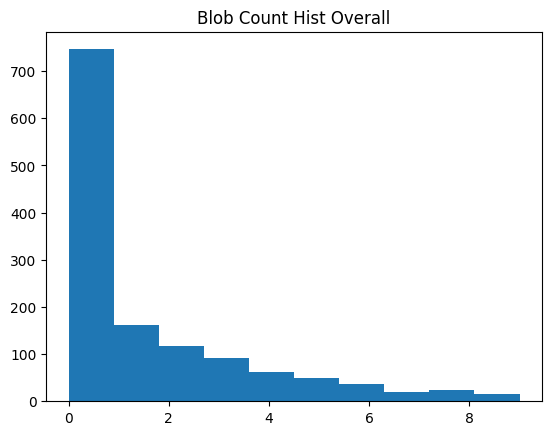

In [454]:
df = pd.DataFrame({'Blobs': train_blobs})
print(df.describe())
plt.hist(train_blobs)
plt.title('Blob Count Hist Overall')
plt.show()

          Healthy
count  458.000000
mean     0.947598
std      1.994929
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      9.000000


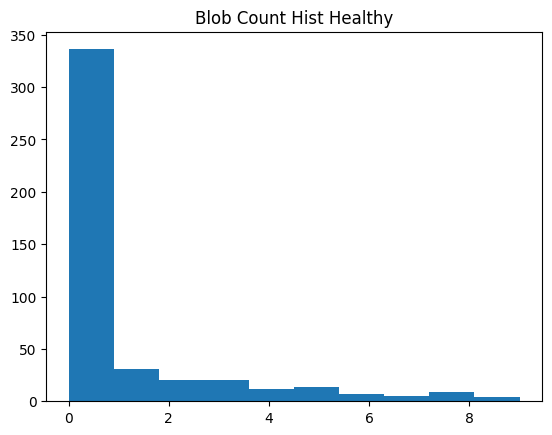

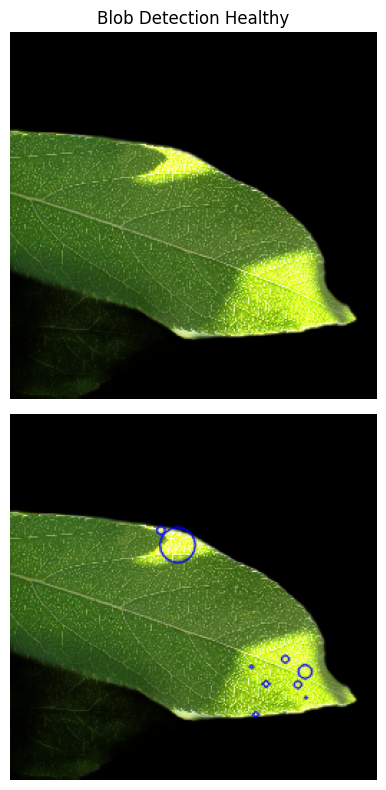

          Powdery
count  430.000000
mean     1.111628
std      2.064599
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      9.000000


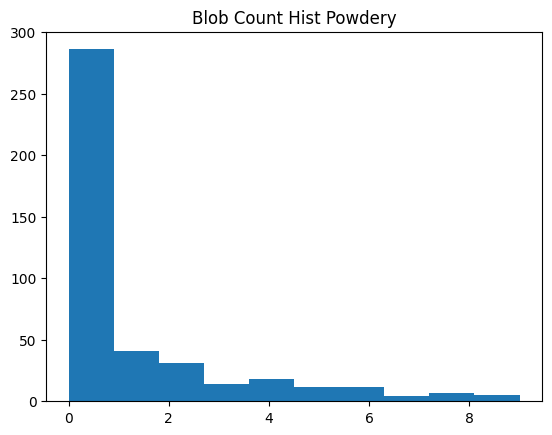

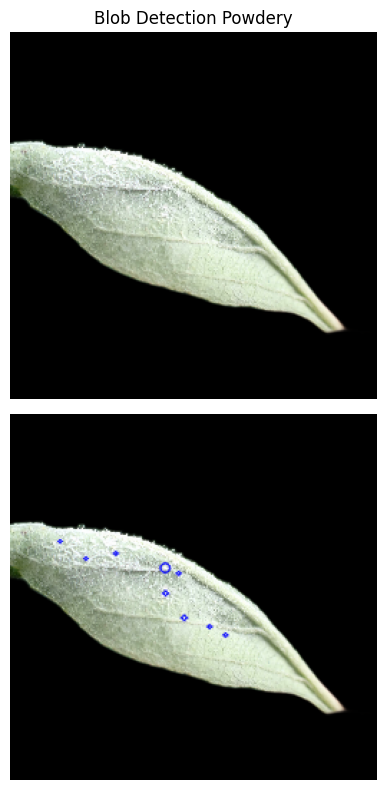

             Rust
count  434.000000
mean     2.168203
std      2.224533
min      0.000000
25%      0.000000
50%      2.000000
75%      3.000000
max      9.000000


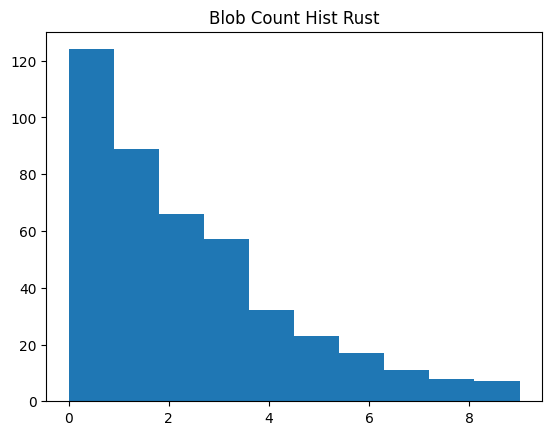

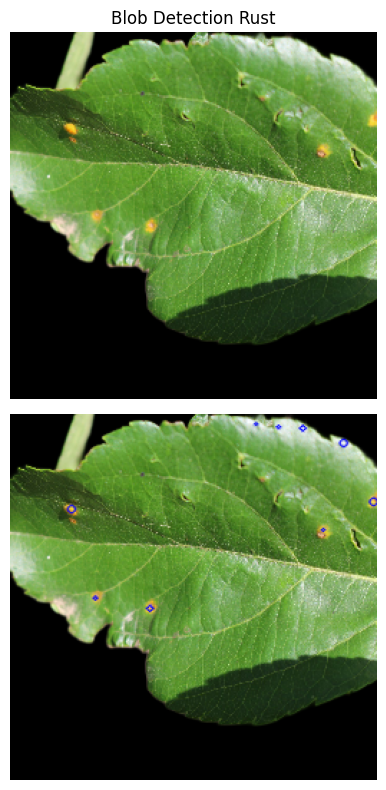

In [450]:
for i, label in enumerate(['Healthy', 'Powdery', 'Rust']):
    filt_data = train_blobs[np.argmax(train_labels, axis=1) == i]
    filt_images = train_images_processed[np.argmax(train_labels, axis=1) == i]
    df = pd.DataFrame({label:filt_data})
    print(df.describe())
    plt.hist(filt_data)
    plt.title('Blob Count Hist ' + label)

    #plot case with most circles per class
    image = filt_images[np.argmax(filt_data)].copy() #find max count image

    img_uint8 = np.clip(image * 255, 0, 255).astype(np.uint8)

    #gray_img = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    gray_img = img_uint8[:, :, 0]
    flat = gray_img.flatten()

    threshold = np.quantile(flat, 0.98)
    abs_threshold = 0.9 * 255

    rounded_gray_image = np.where((gray_img >= threshold) & (gray_img >= abs_threshold), 255, 0).astype(np.uint8)

    # Detect blobs (keypoints)
    detector = cv2.SimpleBlobDetector_create(params)
    blobs = detector.detect(rounded_gray_image)

    output = img_uint8.copy()
    output_with_blobs = cv2.drawKeypoints(
        output,
        blobs,
        np.array([]),
        (0,0,255),
        cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    

    fig, axs = plt.subplots(2, 1, figsize=(12,8))
    axs[0].set_title("Blob Detection " + label)
    axs[0].imshow(img_uint8)
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(output_with_blobs, cv2.COLOR_BGR2RGB))
    axs[1].imshow(output_with_blobs)
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()